<div style="background:linear-gradient(135deg,#7c2d12 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fed7aa;font-weight:700;text-transform:uppercase">Chapter 187 &middot; Capstone 26 &middot; Diagnostics</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">When the Assumptions Fail</div>
  <div style="font-size:15px;color:#fed7aa;max-width:820px;line-height:1.6">Four failures in one dataset. The order you check them in decides whether you find them at all, because each one hides the next. Every diagnosis here gets a repair, not a footnote.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm, statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
OR, DK, LT, MUT, GD, RD = "#c2410c", "#7c2d12", "#fb923c", "#94a3b8", "#047857", "#dc2626"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-regression-diagnostics-and-remedies.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("DailyTrading")
plan  = load("AnalysisPlan")
truth = load("truth")
print("rows in the point-of-sale export:", f"{len(raw):,}")
raw.head()

rows in the point-of-sale export: 1,109


,date,day_of_week,temperature_f,promotion,public_holiday,local_festival,daily_revenue
0,2023-01-01,Sunday,38.6,0,1,0,2500.95
1,2023-01-02,Monday,33.2,1,0,0,1787.41
2,2023-01-03,Tuesday,38.8,0,0,0,1833.14
3,2023-01-04,Wednesday,41.0,0,0,0,2229.43
4,2023-01-05,Thursday,37.8,0,0,0,2037.44


## Step 1 &middot; The decision, and the export it rests on

In [2]:
for line in plan.analysis_plan.fillna(""):
    print(line)

THE DECISION THIS ANALYSIS FEEDS.

The promotion costs 200 dollars a day to run. Marketing wants to know whether it brings in
more than that. The answer is an interval, and the whole question is whether that interval
clears 200.

D1 MODEL: daily revenue on day of week, temperature, promotion, public holiday and a linear
   time trend. This is the model anyone would fit first, and it is where we start.
D2 WE WILL CHECK FOUR THINGS, AND FIX WHAT FAILS:
   (a) constant error variance          -> residuals against fitted values, Breusch-Pagan
   (b) linearity in each predictor      -> residuals against each predictor, RESET
   (c) no single day driving the fit    -> Cook's distance, leverage
   (d) independent errors               -> Durbin-Watson, autocorrelation of residuals
D3 EACH FAILURE GETS A REMEDY, NOT A FOOTNOTE. A diagnostic reported and then ignored is
   worse than one never run, because it creates a record of having known.
D4 WE REPORT WHAT EACH REMEDY CHANGED. If a repair mo

In [3]:
d = raw.drop_duplicates(subset="date").copy()
print(f"raw rows                 {len(raw):,}")
print(f"after the duplicate export {len(d):,}")
d = d.dropna(subset=["daily_revenue"])
print(f"with a till close-out    {len(d):,}")
d.loc[d.temperature_f == -99, "temperature_f"] = np.nan
d = d.dropna(subset=["temperature_f"])
print(f"with a valid temperature {len(d):,}   (-99 is a sensor fault, not a temperature)")
d["date"] = pd.to_datetime(d.date)
d = d.sort_values("date").reset_index(drop=True)
d["t"] = (d.date - d.date.min()).dt.days
print(f"\nrevenue ${d.daily_revenue.min():,.0f} to ${d.daily_revenue.max():,.0f}   "
      f"temperature {d.temperature_f.min():.1f} to {d.temperature_f.max():.1f} F")

raw rows                 1,109
after the duplicate export 1,095
with a till close-out    1,090
with a valid temperature 1,079   (-99 is a sensor fault, not a temperature)

revenue $183 to $6,310   temperature 12.6 to 93.2 F


## Step 2 &middot; First look

Three years of daily takings, one row a day. The model comes next; this is the two minutes before it.

In [4]:
print("DAILY REVENUE")
print(d.daily_revenue.describe(percentiles=[.05,.25,.5,.75,.95]).round(0).to_string())
print(f"  skewness {d.daily_revenue.skew():+.3f}   kurtosis {d.daily_revenue.kurtosis():+.3f}")

print("\nBY DAY OF WEEK")
DOW = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
o = [x for x in DOW if x in set(d.day_of_week)] or sorted(d.day_of_week.unique())
for k in o:
    g = d[d.day_of_week == k]
    print(f"  {str(k):5s} n {len(g):4d}   median {g.daily_revenue.median():>8,.0f}"
          f"   max {g.daily_revenue.max():>9,.0f}")

print("\nHOW OFTEN EACH FLAG IS ON")
for c in ["promotion", "public_holiday", "local_festival"]:
    print(f"  {c:16s} {int(d[c].sum()):4d} days of {len(d):,}")

print("\nTHE LARGEST DAYS IN THE FILE")
print(d.nlargest(8, "daily_revenue")[["date","day_of_week","temperature_f",
      "promotion","public_holiday","daily_revenue"]].to_string(index=False))

DAILY REVENUE
count    1079.0
mean     2868.0
std       587.0
min       183.0
5%       1950.0
25%      2493.0
50%      2867.0
75%      3241.0
95%      3749.0
max      6310.0
  skewness +0.349   kurtosis +2.752

BY DAY OF WEEK
  Friday n  155   median    3,198   max     4,284
  Monday n  155   median    2,569   max     3,772
  Saturday n  151   median    3,257   max     5,826
  Sunday n  155   median    2,953   max     6,310
  Thursday n  153   median    2,812   max     5,806
  Tuesday n  156   median    2,582   max     3,708
  Wednesday n  154   median    2,722   max     3,887

HOW OFTEN EACH FLAG IS ON
  promotion         179 days of 1,079
  public_holiday     20 days of 1,079
  local_festival      6 days of 1,079

THE LARGEST DAYS IN THE FILE
      date day_of_week  temperature_f  promotion  public_holiday  daily_revenue
2025-10-12      Sunday           74.4          0               0        6309.67
2024-06-15    Saturday           72.7          0               0        5825.79
2023-

**What this shows.** Revenue is close to symmetric, and its kurtosis of 2.75 is the number to notice: a handful of days sit a long way from the rest without dragging the bulk of the distribution with them. That is the signature of a few unusual days rather than a skewed process.

Look at the largest eight. Six of them are neither promotion days nor public holidays, they fall on different weekdays, and the dates repeat across years. None of the columns in the model as it stands accounts for them.

Note too that temperature spans a wide range across three years. Whether takings respond to it in a straight line is an assumption nobody has looked at, and it is about to be made.

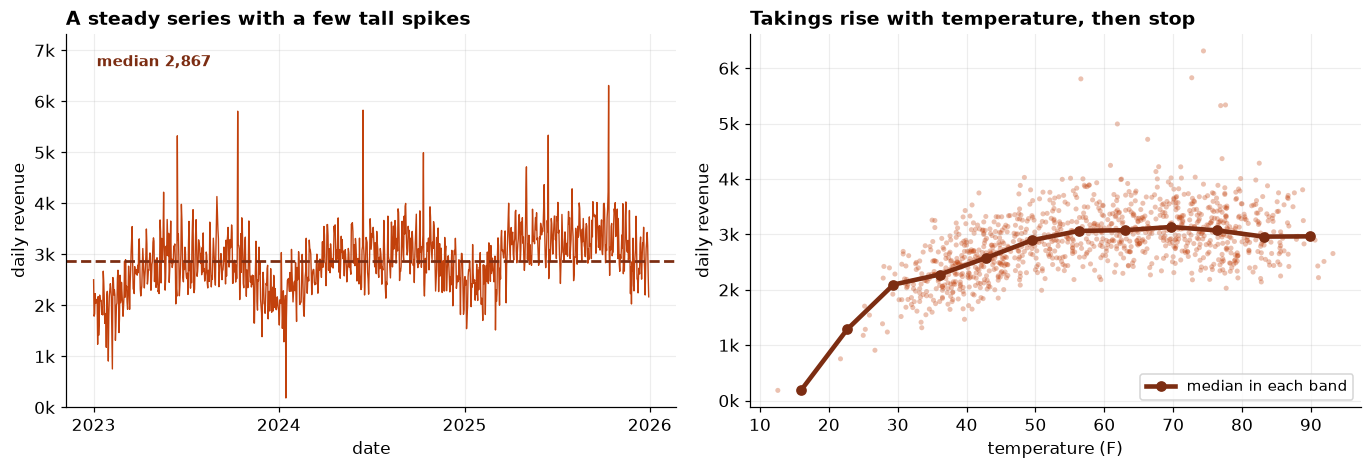

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.plot(d.date, d.daily_revenue, color=OR, lw=0.9)
med = d.daily_revenue.median()
ax.axhline(med, color=DK, lw=1.8, ls="--")
ax.set_ylim(0, d.daily_revenue.max()*1.16)
ax.text(d.date.iloc[6], d.daily_revenue.max()*1.06,
        f"median {med:,.0f}", color=DK, fontsize=9.5, fontweight="bold")
ax.set_xlabel("date"); ax.set_ylabel("daily revenue")
ax.set_xticks(pd.to_datetime(["2023-01-01","2024-01-01","2025-01-01","2026-01-01"]))
ax.set_xticklabels(["2023","2024","2025","2026"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.set_title("A steady series with a few tall spikes")

ax = axes[1]
ax.scatter(d.temperature_f, d.daily_revenue, s=11, alpha=0.32, color=OR, edgecolor="none")
bins = np.linspace(d.temperature_f.min(), d.temperature_f.max(), 13)
mid = (bins[:-1] + bins[1:])/2
bm = [d.loc[(d.temperature_f >= lo) & (d.temperature_f < hi), "daily_revenue"].median()
      for lo, hi in zip(bins[:-1], bins[1:])]
ax.plot(mid, bm, color=DK, lw=3.0, marker="o", ms=6, label="median in each band")
ax.set_xlabel("temperature (F)"); ax.set_ylabel("daily revenue")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.set_title("Takings rise with temperature, then stop")
ax.legend(fontsize=9.5, loc="lower right")
plt.tight_layout(); plt.show()

**Left:** six spikes tower over an otherwise steady series, and there is a run of very low days in the winter of 2024. **Right:** the band medians climb hard from 15 degrees to about 55 and are then flat for the rest of the range. A straight line through that will underpredict the middle and overpredict both ends.

Keep this picture in mind through the next three steps. The formal checks are about to report that the functional form is wrong and that the errors are correlated, and they will take several rounds to separate the two faults. Both were in this chart before any test was run. That is not an argument against the tests, which quantify what a chart can only suggest. It is an argument for looking first.

## Step 3 &middot; The model everyone fits first

In [6]:
NAIVE = "daily_revenue ~ C(day_of_week) + temperature_f + promotion + public_holiday + t"
m0 = smf.ols(NAIVE, d).fit()

def promo(model, label, cov=None, **kw):
    i = list(model.params.index).index("promotion")
    mm = model.get_robustcov_results(cov_type=cov, **kw) if cov else model
    b, se = np.asarray(mm.params)[i], np.asarray(mm.bse)[i]
    lo, hi = b - 1.96*se, b + 1.96*se
    verdict = "clears the $200 cost" if lo > 200 else "does NOT clear $200"
    print(f"{label:42s} {b:+7.1f}   SE {se:5.1f}   95% CI [{lo:6.0f}, {hi:6.0f}]   {verdict}")
    return b, se

promo(m0, "naive OLS")
print(f"\nR-squared {m0.rsquared:.3f}    residual SD ${np.sqrt(m0.mse_resid):.0f}")

naive OLS                                   +295.4   SE  30.7   95% CI [   235,    356]   clears the $200 cost

R-squared 0.602    residual SD $372


**The promotion looks like a clear win.** It brings in about 295 dollars a day against a cost of 200, and the interval is comfortably clear of the break-even. If the analysis stopped here, marketing would get its answer and it would even be roughly right.

Everything that follows is about whether we are entitled to that interval, and about a second conclusion in the same model that is not roughly right at all.

## Step 4 &middot; The four checks, run all at once, which is the wrong way to do it

Run them together first, because that is what most people do and the result is instructive.

In [7]:
def checks(model, label):
    bp = het_breuschpagan(model.resid, model.model.exog)[3]
    rs = linear_reset(model, power=2, use_f=True).pvalue
    dw = durbin_watson(model.resid)
    cd = model.get_influence().cooks_distance[0]
    print(f"{label}")
    print(f"   (a) constant variance   Breusch-Pagan p = {bp:<10.3g} {'PASS' if bp > 0.05 else 'FAIL'}")
    print(f"   (b) correct functional form  RESET p = {rs:<10.3g} {'PASS' if rs > 0.05 else 'FAIL'}")
    print(f"   (c) no dominant observation  max Cook's D = {cd.max():<8.4f} (4/n = {4/len(d):.5f})")
    print(f"   (d) independent errors   Durbin-Watson = {dw:<8.3f} {'PASS' if 1.8 < dw < 2.2 else 'FAIL'}")
    return bp, rs, dw, cd

_ = checks(m0, "NAIVE MODEL")

NAIVE MODEL
   (a) constant variance   Breusch-Pagan p = 0.334      PASS
   (b) correct functional form  RESET p = 4.08e-08   FAIL
   (c) no dominant observation  max Cook's D = 0.0505   (4/n = 0.00371)
   (d) independent errors   Durbin-Watson = 1.265    FAIL


**Three failures and one pass, and the pass is a lie.** The functional form is catastrophically wrong, the errors are correlated, and the variance test says everything is fine. It is not fine. The variance test cannot see the problem because the residuals are dominated by a much larger fault sitting on top of it.

**This is the lesson of the chapter.** These four checks are not a parallel checklist. They are a sequence, because a badly specified mean produces residuals that swamp everything else, and a handful of enormous residuals hides the pattern in the rest.

## Step 5 &middot; Fix the mean structure first

RESET is screaming, so start there. Look at the residuals against each predictor to find out which one is curved.

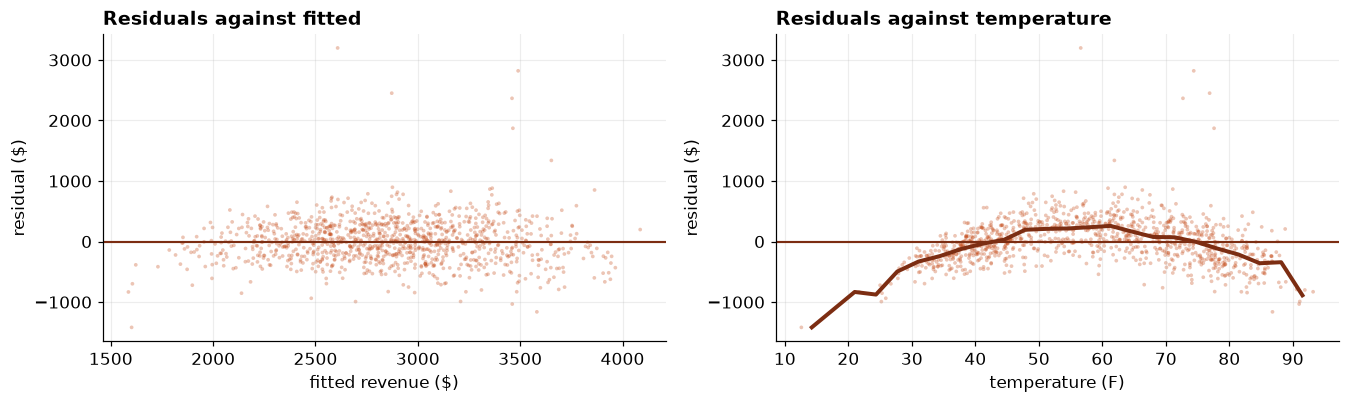

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.8))
axes[0].scatter(m0.fittedvalues, m0.resid, s=6, alpha=0.3, color=OR, edgecolor="none")
axes[0].axhline(0, color=DK, lw=1.4)
axes[0].set_xlabel("fitted revenue ($)"); axes[0].set_ylabel("residual ($)")
axes[0].set_title("Residuals against fitted")
axes[1].scatter(d.temperature_f, m0.resid, s=6, alpha=0.3, color=OR, edgecolor="none")
axes[1].axhline(0, color=DK, lw=1.4)
lo = pd.Series(m0.resid).groupby(pd.cut(d.temperature_f, 24)).mean()
mids = [iv.mid for iv in lo.index]
axes[1].plot(mids, lo.values, color=DK, lw=2.6)
axes[1].set_xlabel("temperature (F)"); axes[1].set_ylabel("residual ($)")
axes[1].set_title("Residuals against temperature")
plt.tight_layout(); plt.show()

**There it is.** Against temperature the residuals arch: the straight line is far too low at both ends and too high in the middle, which is the signature of a curve fitted with a ruler. A café sells less when it is freezing and less when it is sweltering, and a linear term cannot represent both.

In [9]:
SPL = "daily_revenue ~ C(day_of_week) + bs(temperature_f, df=5) + promotion + public_holiday + t"
m1 = smf.ols(SPL, d).fit()
promo(m1, "+ spline on temperature")
print(f"\nR-squared {m0.rsquared:.3f} -> {m1.rsquared:.3f}    "
      f"residual SD ${np.sqrt(m0.mse_resid):.0f} -> ${np.sqrt(m1.mse_resid):.0f}\n")
_ = checks(m1, "AFTER THE SPLINE")

+ spline on temperature                     +291.1   SE  25.6   95% CI [   241,    341]   clears the $200 cost

R-squared 0.602 -> 0.723    residual SD $372 -> $311

AFTER THE SPLINE
   (a) constant variance   Breusch-Pagan p = 0.117      PASS
   (b) correct functional form  RESET p = 0.693      PASS
   (c) no dominant observation  max Cook's D = 0.0599   (4/n = 0.00371)
   (d) independent errors   Durbin-Watson = 1.496    FAIL


**RESET is repaired and the variance test still says nothing.** Durbin-Watson has improved from 1.27 to 1.50 without being touched, which is itself worth noticing: some of what looked like correlated errors was the curve, since a smooth misfit produces runs of same-signed residuals that look exactly like autocorrelation.

But Cook's distance has now sharpened into something specific.

## Step 6 &middot; The six days

In [10]:
cd = m1.get_influence().cooks_distance[0]
top = np.argsort(cd)[-8:][::-1]
print(f"{'date':14s}{'Cook D':>9}{'residual':>11}   what it was")
for i in top:
    tag = "LOCAL FESTIVAL" if d.local_festival.iloc[i] else ""
    print(f"{str(d.date.iloc[i].date()):14s}{cd[i]:>9.4f}{m1.resid.iloc[i]:>11,.0f}   {tag}")
print(f"\nthe six festival days are {d.local_festival.sum()} rows out of {len(d):,}")

date             Cook D   residual   what it was
2025-10-12       0.0599      2,830   LOCAL FESTIVAL
2023-10-12       0.0573      2,974   LOCAL FESTIVAL
2023-06-15       0.0508      2,524   LOCAL FESTIVAL
2024-06-15       0.0343      2,336   LOCAL FESTIVAL
2025-06-15       0.0294      1,967   LOCAL FESTIVAL
2024-01-15       0.0257        -58   
2025-07-31       0.0178        758   
2024-10-12       0.0133      1,147   LOCAL FESTIVAL

the six festival days are 6 rows out of 1,079


**Five of the top six are the local street festival.** The plan said in advance that we would not delete influential points, and this is why the rule is worth having: these are not errors, they are the six most commercially interesting days in three years. An influential observation is an instruction to model something, and deleting it is a decision to report a model of a world that did not happen.

Before fixing it, here is what those six days were doing to the variance test.

In [11]:
print("Breusch-Pagan on the spline model")
print(f"   all days                        p = {het_breuschpagan(m1.resid, m1.model.exog)[3]:.3g}")
sub = d[d.local_festival == 0].reset_index(drop=True)
ms = smf.ols(SPL, sub).fit()
print(f"   festival days removed           p = {het_breuschpagan(ms.resid, ms.model.exog)[3]:.3g}")
r = pd.Series(m1.resid)
print(f"\nresidual SD, all days ${r.std():.0f}   excluding those six ${r[d.local_festival.values == 0].std():.0f}")
print("\nSix days out of 1,079 inflate the residual spread by 22 percent, and that is")
print("enough to bury a variance pattern that is otherwise overwhelming.")

Breusch-Pagan on the spline model
   all days                        p = 0.117
   festival days removed           p = 1.32e-08

residual SD, all days $309   excluding those six $253

Six days out of 1,079 inflate the residual spread by 22 percent, and that is
enough to bury a variance pattern that is otherwise overwhelming.


In [12]:
FULL = SPL + " + local_festival"
m2 = smf.ols(FULL, d).fit()
promo(m2, "+ festival indicator")
print(f"\nfestival effect  ${m2.params['local_festival']:+,.0f} per day   (truth: +$2,600)")
print(f"R-squared {m1.rsquared:.3f} -> {m2.rsquared:.3f}    "
      f"residual SD ${np.sqrt(m1.mse_resid):.0f} -> ${np.sqrt(m2.mse_resid):.0f}\n")
_ = checks(m2, "AFTER MODELING THE FESTIVALS")

+ festival indicator                        +288.0   SE  21.3   95% CI [   246,    330]   clears the $200 cost

festival effect  $+2,340 per day   (truth: +$2,600)
R-squared 0.723 -> 0.810    residual SD $311 -> $258

AFTER MODELING THE FESTIVALS
   (a) constant variance   Breusch-Pagan p = 7.06e-18   FAIL
   (b) correct functional form  RESET p = 0.0412     FAIL
   (c) no dominant observation  max Cook's D = 0.3316   (4/n = 0.00371)
   (d) independent errors   Durbin-Watson = 1.131    FAIL


**And now the variance test fires, at p = 7 &#215; 10&#8315;&#185;&#8312;.** Nothing about the variance changed between the last model and this one. What changed is that the six residuals concealing it are no longer there, because the model now knows those days were festivals.

Note also what modeling rather than deleting bought: **a festival is worth about 2,340 dollars a day**, which is a genuinely useful number the business did not have. Deleting the rows would have thrown it away and left the analyst with a cleaner-looking residual plot and less knowledge.

Two lines in that output look like they got worse, and neither did.

**Cook's distance rose from 0.06 to 0.33.** The influence did not appear, it moved. The festival coefficient is estimated from six observations, so each of those six is by construction decisive for it. That is what it means to fit an indicator to a rare event, and it is a reason to report the coefficient with its six-day sample size attached rather than a reason to remove the term.

**RESET now returns p = 0.04.** With 1,079 observations this test detects departures far too small to matter; the residual-against-temperature curve in the next figure is flat to within a few dollars across the whole range. A marginal RESET on a large sample is a prompt to look at a picture, not an instruction to add another term.

## Step 7 &middot; Standard errors for the two faults that remain

Heteroskedasticity and autocorrelation both attack the same thing: they leave the coefficients alone and make the standard errors wrong. The repair is not to change the model but to change how its uncertainty is computed.

In [13]:
print(f"{'':42s} {'estimate':>8}   {'SE':>5}   95% interval")
promo(m2, "classical SE (assumes neither fault)")
promo(m2, "HC3 robust (heteroskedasticity only)", cov="HC3")
promo(m2, "Newey-West HAC, 14 lags (both faults)", cov="HAC", maxlags=14, use_correction=True)
print("\nThe estimate does not move. Only the width of the interval does, which is")
print("exactly what these two violations damage.")

                                           estimate      SE   95% interval
classical SE (assumes neither fault)        +288.0   SE  21.3   95% CI [   246,    330]   clears the $200 cost
HC3 robust (heteroskedasticity only)        +288.0   SE  24.2   95% CI [   241,    335]   clears the $200 cost
Newey-West HAC, 14 lags (both faults)       +288.0   SE  23.1   95% CI [   243,    333]   clears the $200 cost

The estimate does not move. Only the width of the interval does, which is
exactly what these two violations damage.


## Step 8 &middot; What the repairs actually changed

Two conclusions came out of this model. The repairs treated them very differently.

In [14]:
print("CONCLUSION 1: is the promotion worth its $200 a day?\n")
for lab, mod, kw in [("naive OLS", m0, {}), ("spline", m1, {}), ("spline + festival", m2, {}),
                     ("spline + festival, HAC SE", m2, dict(cov="HAC", maxlags=14, use_correction=True))]:
    promo(mod, "   " + lab, **kw)
print(f"\n   truth: ${truth.loc[truth.quantity.str.contains('promotion effect'), 'value'].iloc[0]:.0f}")
print("   Every specification reaches the same decision. The repairs did not rescue")
print("   this answer; they sharpened it, from a residual SD of $372 down to $258.")

CONCLUSION 1: is the promotion worth its $200 a day?

   naive OLS                                +295.4   SE  30.7   95% CI [   235,    356]   clears the $200 cost
   spline                                   +291.1   SE  25.6   95% CI [   241,    341]   clears the $200 cost
   spline + festival                        +288.0   SE  21.3   95% CI [   246,    330]   clears the $200 cost
   spline + festival, HAC SE                +288.0   SE  23.1   95% CI [   243,    333]   clears the $200 cost

   truth: $250
   Every specification reaches the same decision. The repairs did not rescue
   this answer; they sharpened it, from a residual SD of $372 down to $258.


In [15]:
print("CONCLUSION 2: how does temperature affect trade?\n")
print(f"   naive straight line:  {m0.params['temperature_f']:+.2f} dollars per degree, "
      f"everywhere   (p = {m0.pvalues['temperature_f']:.1e})")
lo_t, hi_t = d.temperature_f.min(), d.temperature_f.max()
grid = pd.DataFrame({"temperature_f": np.linspace(lo_t, hi_t, 200)})
for c, v in [("day_of_week", "Wednesday"), ("promotion", 0), ("public_holiday", 0),
             ("local_festival", 0), ("t", float(d.t.median()))]:
    grid[c] = v
pred = m2.predict(grid)
peak = float(grid.temperature_f.iloc[int(np.argmax(pred))])
print(f"   repaired model:       revenue peaks at {peak:.1f} F and falls away on both sides")
for tf in (20, 40, 55, 67, 80, 90):
    i = int(np.argmin(np.abs(grid.temperature_f - tf)))
    print(f"        {tf:>3} F  ${pred.iloc[i]:,.0f}")
above = (float(pred.iloc[-1]) - float(pred.max())) / (hi_t - peak)
print(f"\n   above the peak the real slope is about {above:+.1f} dollars per degree.")
print(f"   The naive model says {m0.params['temperature_f']:+.1f} at every temperature, so on hot days")
print("   it has the sign backwards. THIS is the conclusion the repairs changed.")

CONCLUSION 2: how does temperature affect trade?

   naive straight line:  +16.96 dollars per degree, everywhere   (p = 7.1e-105)
   repaired model:       revenue peaks at 67.3 F and falls away on both sides
         20 F  $1,022
         40 F  $2,302
         55 F  $2,823
         67 F  $2,930
         80 F  $2,835
         90 F  $2,635

   above the peak the real slope is about -14.6 dollars per degree.
   The naive model says +17.0 at every temperature, so on hot days
   it has the sign backwards. THIS is the conclusion the repairs changed.


**One conclusion survived and one did not.** The promotion answer was right all along and merely overconfident; the temperature answer was wrong in direction across the whole upper half of the range. A manager using the naive model to plan staffing for a heatwave would staff up for a rush that does not come.

That asymmetry is the honest summary of diagnostics work. Most of the time the repairs change how sure you are entitled to be. Occasionally they change the answer, and you cannot tell which case you are in without doing them.

## Step 9 &middot; The four signatures, side by side

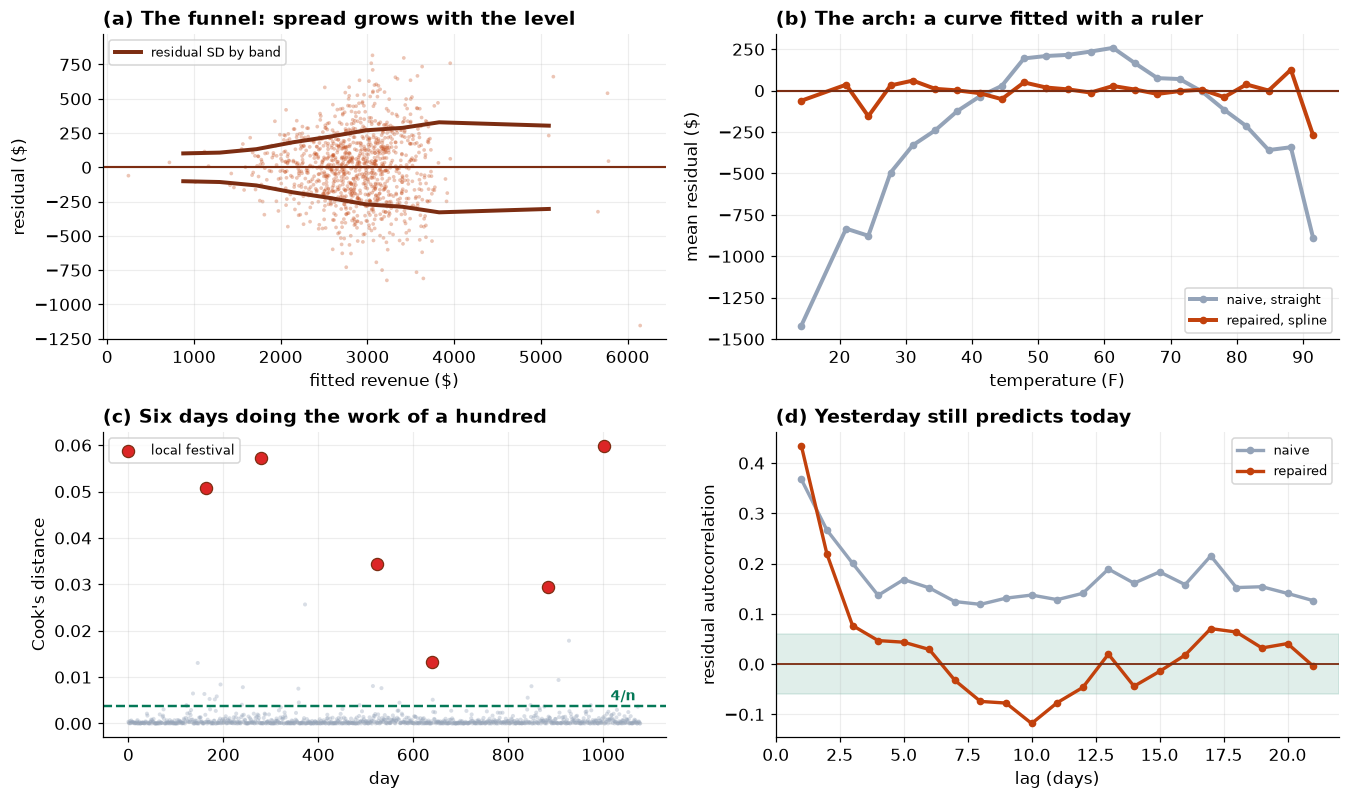

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12.4, 7.4))

ax = axes[0,0]
fit2, res2 = m2.fittedvalues, m2.resid
ax.scatter(fit2, res2, s=6, alpha=0.3, color=OR, edgecolor="none")
ax.axhline(0, color=DK, lw=1.4)
bins = pd.cut(fit2, 14)
sd = res2.groupby(bins, observed=True).std()
ctr = [iv.mid for iv in sd.index]
ax.plot(ctr, sd.values, color=DK, lw=2.6, label="residual SD by band")
ax.plot(ctr, -sd.values, color=DK, lw=2.6)
ax.set_xlabel("fitted revenue ($)"); ax.set_ylabel("residual ($)")
ax.set_title("(a) The funnel: spread grows with the level")
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[0,1]
for mod, col, lab in [(m0, MUT, "naive, straight"), (m2, OR, "repaired, spline")]:
    lo_ = pd.Series(mod.resid).groupby(pd.cut(d.temperature_f, 24)).mean()
    ax.plot([iv.mid for iv in lo_.index], lo_.values, color=col, lw=2.6, marker="o", ms=4, label=lab)
ax.axhline(0, color=DK, lw=1.4)
ax.set_xlabel("temperature (F)"); ax.set_ylabel("mean residual ($)")
ax.set_title("(b) The arch: a curve fitted with a ruler"); ax.legend(fontsize=8.5)

ax = axes[1,0]
cd0 = m1.get_influence().cooks_distance[0]
fest = d.local_festival.values == 1
ax.scatter(np.arange(len(d))[~fest], cd0[~fest], s=7, alpha=0.35, color=MUT, edgecolor="none")
ax.scatter(np.arange(len(d))[fest], cd0[fest], s=64, color=RD, edgecolor=DK, lw=0.8,
           zorder=5, label="local festival")
ax.axhline(4/len(d), color=GD, lw=1.6, ls="--")
ax.text(len(d)*0.99, 4/len(d)*1.35, "4/n", ha="right", fontsize=9, color=GD, fontweight="bold")
ax.set_xlabel("day"); ax.set_ylabel("Cook's distance")
ax.set_title("(c) Six days doing the work of a hundred"); ax.legend(fontsize=8.5)

ax = axes[1,1]
for mod, col, lab in [(m0, MUT, "naive"), (m2, OR, "repaired")]:
    r_ = pd.Series(np.asarray(mod.resid))
    ac = [r_.autocorr(k) for k in range(1, 22)]
    ax.plot(range(1, 22), ac, color=col, lw=2.2, marker="o", ms=4, label=lab)
ax.axhline(0, color=DK, lw=1.2)
band = 1.96/np.sqrt(len(d))
ax.axhspan(-band, band, color=GD, alpha=0.12)
ax.set_xlabel("lag (days)"); ax.set_ylabel("residual autocorrelation")
ax.set_title("(d) Yesterday still predicts today"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**(a)** The residual spread against fitted revenue, with the standard error of the residuals in each band drawn as an envelope. It widens steadily, roughly tripling from the quiet end of the range to the busy end, which is the funnel the Breusch-Pagan test is detecting. **(b)** The naive residuals arch by more than 400 dollars across the temperature range; the repaired ones are flat. **(c)** The six festival days stand far above every other day, and the dashed 4/n line shows why that rule flags too much to be useful on its own. **(d)** Autocorrelation falls with the repairs and does not vanish, which is exactly why the final model uses HAC standard errors rather than pretending.

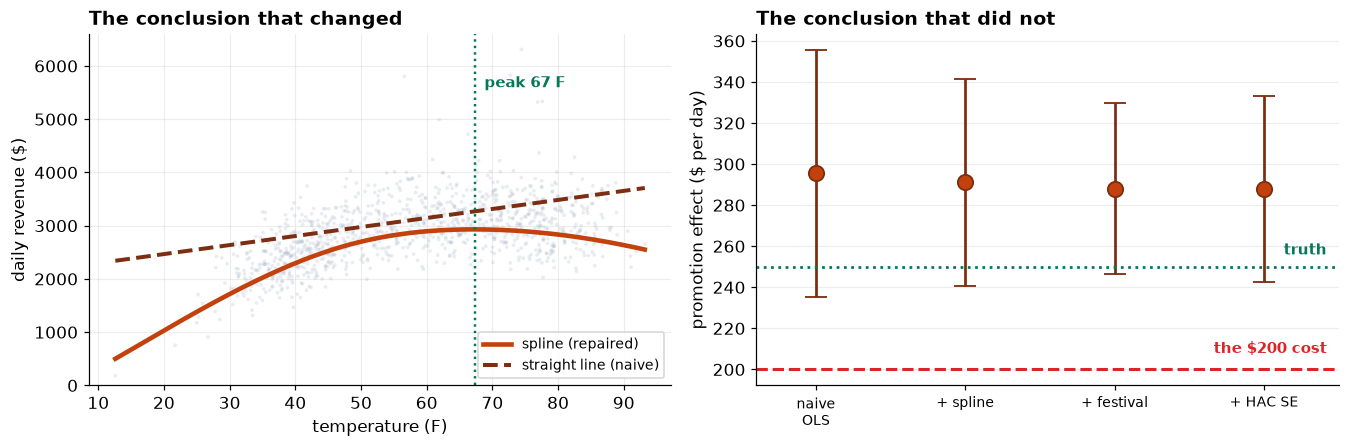

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

ax = axes[0]
ax.scatter(d.temperature_f, d.daily_revenue, s=6, alpha=0.2, color=MUT, edgecolor="none")
ax.plot(grid.temperature_f, pred, color=OR, lw=3, label="spline (repaired)")
xs = np.array([lo_t, hi_t])
base = m0.params["Intercept"] + m0.params["t"]*float(d.t.median())
ax.plot(xs, base + m0.params["temperature_f"]*xs, color=DK, lw=2.6, ls="--", label="straight line (naive)")
ax.axvline(peak, color=GD, lw=1.6, ls=":")
ax.text(peak+1.5, 5600, f"peak {peak:.0f} F", color=GD, fontweight="bold", fontsize=9.5)
ax.set_xlabel("temperature (F)"); ax.set_ylabel("daily revenue ($)")
ax.set_ylim(0, 6600); ax.set_title("The conclusion that changed"); ax.legend(fontsize=9, loc="lower right")

ax = axes[1]
labs, ests, ses = [], [], []
for lab, mod, kw in [("naive\nOLS", m0, {}), ("+ spline", m1, {}), ("+ festival", m2, {}),
                     ("+ HAC SE", m2, dict(cov_type="HAC", maxlags=14, use_correction=True))]:
    i = list(mod.params.index).index("promotion")
    mm = mod.get_robustcov_results(**kw) if kw else mod
    labs.append(lab); ests.append(np.asarray(mm.params)[i]); ses.append(np.asarray(mm.bse)[i])
ests, ses = np.array(ests), np.array(ses)
ax.errorbar(range(4), ests, yerr=1.96*ses, fmt="o", ms=10, color=OR, ecolor=DK,
            elinewidth=1.8, capsize=7, mec=DK, mew=1.2)
ax.axhline(200, color=RD, lw=2, ls="--")
ax.text(3.42, 208, "the $200 cost", ha="right", color=RD, fontweight="bold", fontsize=9.5)
ax.axhline(250, color=GD, lw=1.8, ls=":")
ax.text(3.42, 256, "truth", ha="right", color=GD, fontweight="bold", fontsize=9.5)
ax.set_xticks(range(4)); ax.set_xticklabels(labs, fontsize=9)
ax.set_xlim(-0.4, 3.5); ax.set_ylabel("promotion effect ($ per day)")
ax.set_title("The conclusion that did not"); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Left:** the straight line and the spline through the same data. They agree around the middle of the range and disagree completely at both ends, which is where the operational decisions get made. **Right:** the promotion estimate at each stage, against its cost and against the truth. Every interval clears 200 dollars, and the repairs narrowed it rather than rescuing it.

## Step 10 &middot; Ethics, bias, and limits
- **Run the checks in order, and re-run them after every repair.** A badly specified mean makes the variance test useless and imitates correlated errors. Six extreme residuals hide a variance pattern in a thousand ordinary ones. A checklist run once, in parallel, finds one of the four faults here.
- **Never delete an influential point to improve a fit.** Those six days were the festival. Deleting them tidies the residual plot, moves the promotion estimate by eight dollars, and discards a 2,340-dollar-a-day finding the business would have wanted.
- **Report the diagnostics you ran, including the ones that passed.** A reader cannot distinguish "we checked and it was fine" from "we did not check", and only one of those deserves their trust.
- **Robust standard errors are not a licence to skip the model.** HC3 and HAC repair the uncertainty around a coefficient. They do nothing whatever about a curve fitted with a ruler, and applying them to a misspecified model produces a confident answer to the wrong question.
- **Say which conclusion the repairs changed.** Here the promotion answer survived and the temperature answer reversed above 67 degrees. Reporting only that "diagnostics were performed" tells a reader nothing about which of your findings depended on them.
- **A model that fits well can still be the wrong shape.** The naive model had an R-squared of 0.60 and a temperature coefficient significant at p = 7 &#215; 10&#8315;&#185;&#8304;&#8309;. Both numbers were real and neither of them noticed that the relationship bends.

---
**From analysis to report.** The notebook carries the chain: the model anyone would fit first, four checks run in parallel and only one fault found, the mean structure repaired, the influence plot that fingers six specific days, the demonstration that those six were hiding the variance pattern, an event indicator rather than a deletion, HAC standard errors for what remains, and a clear statement of which of the two conclusions the whole exercise changed. The written reports turn it into guidance an owner can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.